In [21]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import os
import time
from datetime import datetime
from IPython.display import display

# Scikit-learn импорты
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.inspection import permutation_importance

# Настройки
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


print("Библиотеки загружены")

Библиотеки загружены


In [22]:
# --- 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ---
print("\n" + "="*60)
print("1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ")
print("="*60)

# Загрузка данных
df = pd.read_csv('S06-hw-dataset-01.csv')
print(f"Загружено данных: {df.shape[0]} строк, {df.shape[1]} столбцов")

# Базовый анализ
print(f"\nРаспределение классов:")
print(df['target'].value_counts(normalize=True))

# Удаление id и подготовка данных
X = df.drop(['id', 'target'], axis=1)
y = df['target']

# One-hot encoding для категориальных признаков
categorical_cols = ['cat_contract', 'cat_region', 'cat_payment']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"\nПризнаки после обработки: {X.shape[1]} столбцов")


1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
Загружено данных: 12000 строк, 30 столбцов

Распределение классов:
target
0    0.676583
1    0.323417
Name: proportion, dtype: float64

Признаки после обработки: 34 столбцов


In [23]:
# --- 2. РАЗДЕЛЕНИЕ ДАННЫХ  ---
print("\n" + "="*60)
print("2. РАЗДЕЛЕНИЕ ДАННЫХ НА TRAIN/TEST")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"Train: {X_train.shape} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape} ({X_test.shape[0]/len(X)*100:.1f}%)")

# Сохраняем индексы для воспроизводимости
split_info = {
    'train_indices': X_train.index.tolist(),
    'test_indices': X_test.index.tolist(),
    'random_state': RANDOM_STATE,
    'test_size': 0.2
}

with open('artifacts/data_split_info.json', 'w') as f:
    json.dump(split_info, f, indent=2)


2. РАЗДЕЛЕНИЕ ДАННЫХ НА TRAIN/TEST
Train: (9600, 34) (80.0%)
Test:  (2400, 34) (20.0%)


In [24]:
# --- 3. БАЗОВЫЕ МОДЕЛИ  ---
print("\n" + "="*60)
print("3. ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛЕЙ")
print("="*60)

# Словарь для хранения всех моделей и метрик
all_models = {}
all_metrics = []

# Функция для однократной оценки модели на тесте
def evaluate_model_once(model, X_test, y_test, model_name):
    """Оценка модели на тестовых данных (выполняется один раз)"""
    start_time = time.time()
    y_pred = model.predict(X_test)
    
    # Получение вероятностей для ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        roc_auc = None
    
    predict_time = time.time() - start_time
    
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc,
        'predict_time': predict_time
    }
    
    return metrics, y_pred, y_proba



3. ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛЕЙ


In [25]:
# --- 3.1. DUMMY CLASSIFIER ---
print("\n3.1. DUMMY CLASSIFIER")
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_metrics, y_pred_dummy, y_proba_dummy = evaluate_model_once(dummy, X_test, y_test, "Dummy")
all_models['Dummy'] = dummy
all_metrics.append(dummy_metrics)
print(f"  Accuracy: {dummy_metrics['accuracy']:.4f}, F1: {dummy_metrics['f1']:.4f}")


3.1. DUMMY CLASSIFIER
  Accuracy: 0.5754, F1: 0.3405


In [26]:
# --- 3.2. LOGISTIC REGRESSION ---
print("\n3.2. LOGISTIC REGRESSION")
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])
lr_pipeline.fit(X_train, y_train)
lr_metrics, y_pred_lr, y_proba_lr = evaluate_model_once(lr_pipeline, X_test, y_test, "LogisticRegression")
all_models['LogisticRegression'] = lr_pipeline
all_metrics.append(lr_metrics)
print(f"  Accuracy: {lr_metrics['accuracy']:.4f}, F1: {lr_metrics['f1']:.4f}")


3.2. LOGISTIC REGRESSION
  Accuracy: 0.8271, F1: 0.7071


In [27]:
# --- 3.3. DECISION TREE С КОНТРОЛЕМ СЛОЖНОСТИ ---
print("\n3.3. DECISION TREE (с контролем сложности)")

# Параметры контроля сложности дерева
param_grid_tree = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_leaf_nodes': [None, 10, 20, 50],
    'min_impurity_decrease': [0.0, 0.001, 0.01],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.1]  # Minimal Cost-Complexity Pruning
}

# GridSearchCV ТОЛЬКО на train данных
grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_tree,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

print("  Подбор параметров на train (GridSearchCV)...")
grid_tree.fit(X_train, y_train)

# Используем лучшую модель
best_tree = grid_tree.best_estimator_
tree_metrics, y_pred_tree, y_proba_tree = evaluate_model_once(best_tree, X_test, y_test, "DecisionTree")
all_models['DecisionTree'] = best_tree
all_metrics.append(tree_metrics)

print(f"  Лучшие параметры:")
for param, value in grid_tree.best_params_.items():
    print(f"    {param}: {value}")
print(f"  CV ROC-AUC: {grid_tree.best_score_:.4f}")
print(f"  Test Accuracy: {tree_metrics['accuracy']:.4f}, F1: {tree_metrics['f1']:.4f}")



3.3. DECISION TREE (с контролем сложности)
  Подбор параметров на train (GridSearchCV)...
  Лучшие параметры:
    ccp_alpha: 0.001
    criterion: entropy
    max_depth: 10
    max_leaf_nodes: None
    min_impurity_decrease: 0.0
    min_samples_leaf: 10
    min_samples_split: 2
  CV ROC-AUC: 0.9088
  Test Accuracy: 0.8658, F1: 0.7821


In [28]:
# --- 3.4. RANDOM FOREST ---
print("\n3.4. RANDOM FOREST")

# Ограниченная сетка для скорости
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

print("  Подбор параметров на train (GridSearchCV)...")
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
rf_metrics, y_pred_rf, y_proba_rf = evaluate_model_once(best_rf, X_test, y_test, "RandomForest")
all_models['RandomForest'] = best_rf
all_metrics.append(rf_metrics)

print(f"  Лучшие параметры: {grid_rf.best_params_}")
print(f"  CV ROC-AUC: {grid_rf.best_score_:.4f}")
print(f"  Test Accuracy: {rf_metrics['accuracy']:.4f}, F1: {rf_metrics['f1']:.4f}")


3.4. RANDOM FOREST
  Подбор параметров на train (GridSearchCV)...
  Лучшие параметры: {'bootstrap': False, 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
  CV ROC-AUC: 0.9700
  Test Accuracy: 0.9275, F1: 0.8826


In [29]:
# --- 3.5. GRADIENT BOOSTING ---
print("\n3.5. GRADIENT BOOSTING")

param_grid_gb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 1.0]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid_gb,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

print("  Подбор параметров на train (GridSearchCV)...")
grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
gb_metrics, y_pred_gb, y_proba_gb = evaluate_model_once(best_gb, X_test, y_test, "GradientBoosting")
all_models['GradientBoosting'] = best_gb
all_metrics.append(gb_metrics)

print(f"  Лучшие параметры: {grid_gb.best_params_}")
print(f"  CV ROC-AUC: {grid_gb.best_score_:.4f}")
print(f"  Test Accuracy: {gb_metrics['accuracy']:.4f}, F1: {gb_metrics['f1']:.4f}")


3.5. GRADIENT BOOSTING
  Подбор параметров на train (GridSearchCV)...
  Лучшие параметры: {'learning_rate': 0.2, 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 150, 'subsample': 1.0}
  CV ROC-AUC: 0.9727
  Test Accuracy: 0.9342, F1: 0.8954


In [30]:
# --- 3.6. STACKING (ОПЦИОНАЛЬНО) ---
print("\n3.6. STACKING CLASSIFIER")

# Используем лучшие версии моделей для стекинга
estimators = [
    ('lr', lr_pipeline),
    ('tree', best_tree),
    ('rf', best_rf),
    ('gb', best_gb)
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
)

print("  Обучение стекинга на train...")
stacking.fit(X_train, y_train)

stacking_metrics, y_pred_stacking, y_proba_stacking = evaluate_model_once(
    stacking, X_test, y_test, "Stacking"
)
all_models['Stacking'] = stacking
all_metrics.append(stacking_metrics)

print(f"  Test Accuracy: {stacking_metrics['accuracy']:.4f}, F1: {stacking_metrics['f1']:.4f}")


3.6. STACKING CLASSIFIER
  Обучение стекинга на train...
  Test Accuracy: 0.9363, F1: 0.8997


In [31]:
# --- 4. ВЫБОР ЛУЧШЕЙ МОДЕЛИ ПО CV РЕЗУЛЬТАТАМ (НЕ ПО TEST!) ---
print("\n" + "="*60)
print("4. ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по CV результатам)")
print("="*60)

# Собираем CV результаты
cv_results = {
    'DecisionTree': grid_tree.best_score_,
    'RandomForest': grid_rf.best_score_,
    'GradientBoosting': grid_gb.best_score_
}

# Выбираем лучшую модель по CV ROC-AUC
best_cv_model = max(cv_results, key=cv_results.get)
best_cv_score = cv_results[best_cv_model]

print(f"Лучшая модель по CV ROC-AUC: {best_cv_model} ({best_cv_score:.4f})")

# Тестовая оценка только для финального отчета
print("\nСводная таблица метрик на тесте:")
metrics_df = pd.DataFrame(all_metrics)
metrics_df = metrics_df.sort_values('roc_auc', ascending=False)
display(metrics_df)


4. ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по CV результатам)
Лучшая модель по CV ROC-AUC: GradientBoosting (0.9727)

Сводная таблица метрик на тесте:


,model,accuracy,f1,roc_auc,predict_time
5,Stacking,0.936250,0.899672,0.971509,0.089881
4,GradientBoosting,0.934167,0.895364,0.970094,0.024248
3,RandomForest,0.927500,0.882591,0.968687,0.079362
2,DecisionTree,0.865833,0.782138,0.911320,0.004588
1,LogisticRegression,0.827083,0.707128,0.875229,0.009641
0,Dummy,0.575417,0.340453,0.513671,0.003292


In [32]:
# --- 5. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ GRIDSEARCH ---
print("\n" + "="*60)
print("5. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ПОДБОРА ПАРАМЕТРОВ")
print("="*60)

search_summaries = {
    "DecisionTree": {
        "best_params": grid_tree.best_params_,
        "best_score": float(grid_tree.best_score_),
        "scoring": "roc_auc",
        "cv_folds": 3,
        "control_complexity": {
            "max_depth": grid_tree.best_params_.get('max_depth', 'Not specified'),
            "min_samples_leaf": grid_tree.best_params_.get('min_samples_leaf', 'Not specified'),
            "min_samples_split": grid_tree.best_params_.get('min_samples_split', 'Not specified'),
            "min_impurity_decrease": grid_tree.best_params_.get('min_impurity_decrease', 'Not specified'),
            "ccp_alpha": grid_tree.best_params_.get('ccp_alpha', 'Not specified'),
            "max_leaf_nodes": grid_tree.best_params_.get('max_leaf_nodes', 'Not specified')
        }
    },
    "RandomForest": {
        "best_params": grid_rf.best_params_,
        "best_score": float(grid_rf.best_score_),
        "scoring": "roc_auc",
        "cv_folds": 3
    },
    "GradientBoosting": {
        "best_params": grid_gb.best_params_,
        "best_score": float(grid_gb.best_score_),
        "scoring": "roc_auc",
        "cv_folds": 3
    }
}

# Сохраняем в файл
with open('artifacts/search_summaries.json', 'w') as f:
    json.dump(search_summaries, f, indent=2)

print("✓ search_summaries.json сохранен")
print("\nКраткое содержание:")
for model, info in search_summaries.items():
    print(f"\n{model}:")
    print(f"  CV ROC-AUC: {info['best_score']:.4f}")
    if 'control_complexity' in info:
        print(f"  Контроль сложности:")
        for param, value in info['control_complexity'].items():
            print(f"    {param}: {value}")


5. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ПОДБОРА ПАРАМЕТРОВ
✓ search_summaries.json сохранен

Краткое содержание:

DecisionTree:
  CV ROC-AUC: 0.9088
  Контроль сложности:
    max_depth: 10
    min_samples_leaf: 10
    min_samples_split: 2
    min_impurity_decrease: 0.0
    ccp_alpha: 0.001
    max_leaf_nodes: None

RandomForest:
  CV ROC-AUC: 0.9700

GradientBoosting:
  CV ROC-AUC: 0.9727



6. АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ: GradientBoosting


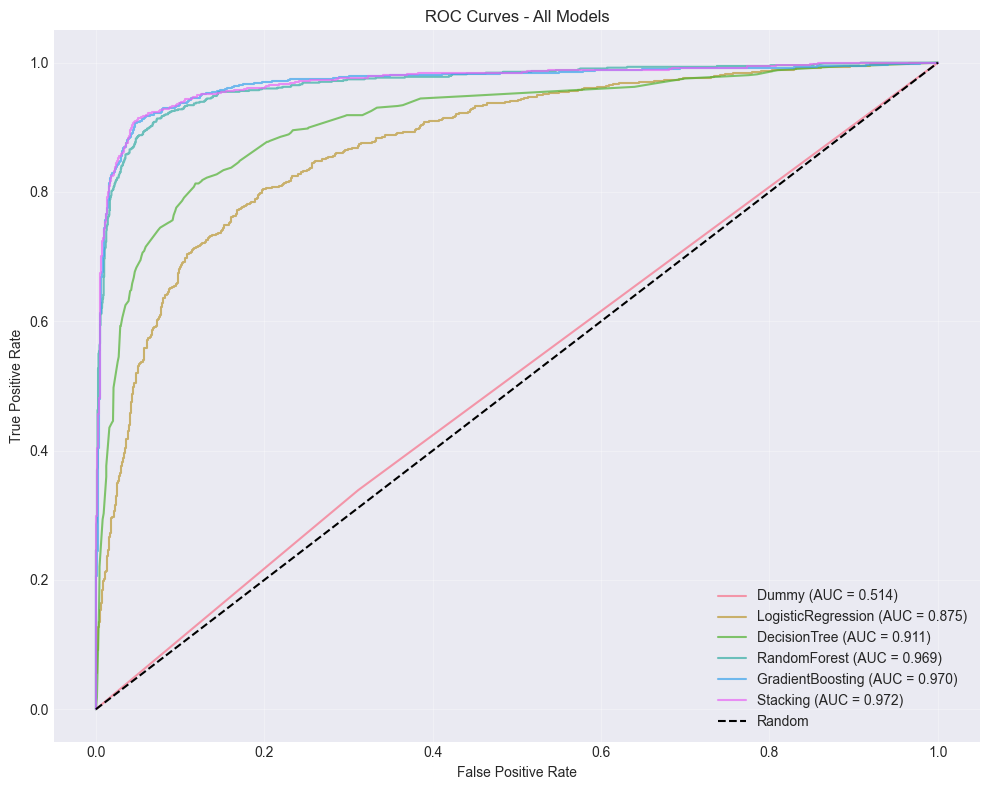

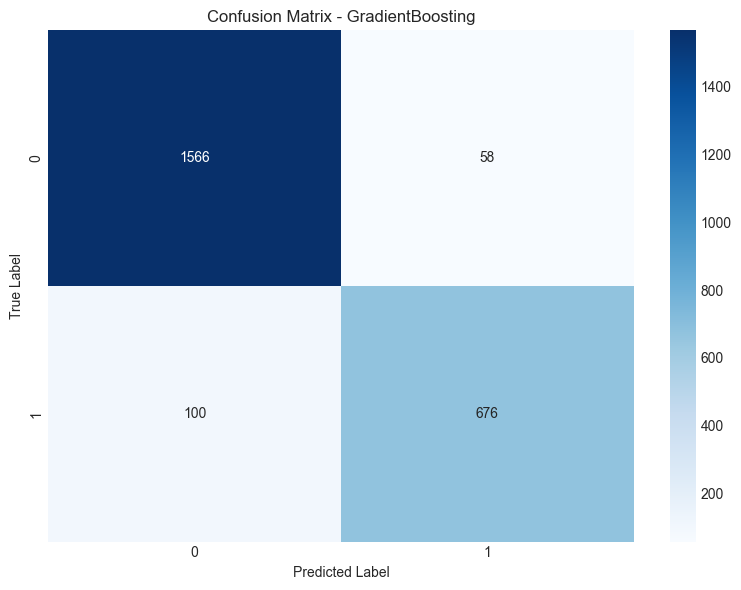


Permutation Importance для GradientBoosting:

Топ-10 важных признаков:


,feature,importance_mean,importance_std
17,num18,0.075827,0.004996
18,num19,0.069514,0.003186
6,num07,0.033314,0.001229
3,num04,0.015888,0.001600
19,num20,0.011182,0.001523
23,num24,0.010698,0.001480
0,num01,0.008446,0.001071
13,num14,0.007659,0.000856
15,num16,0.005959,0.001118
21,num22,0.005847,0.001037


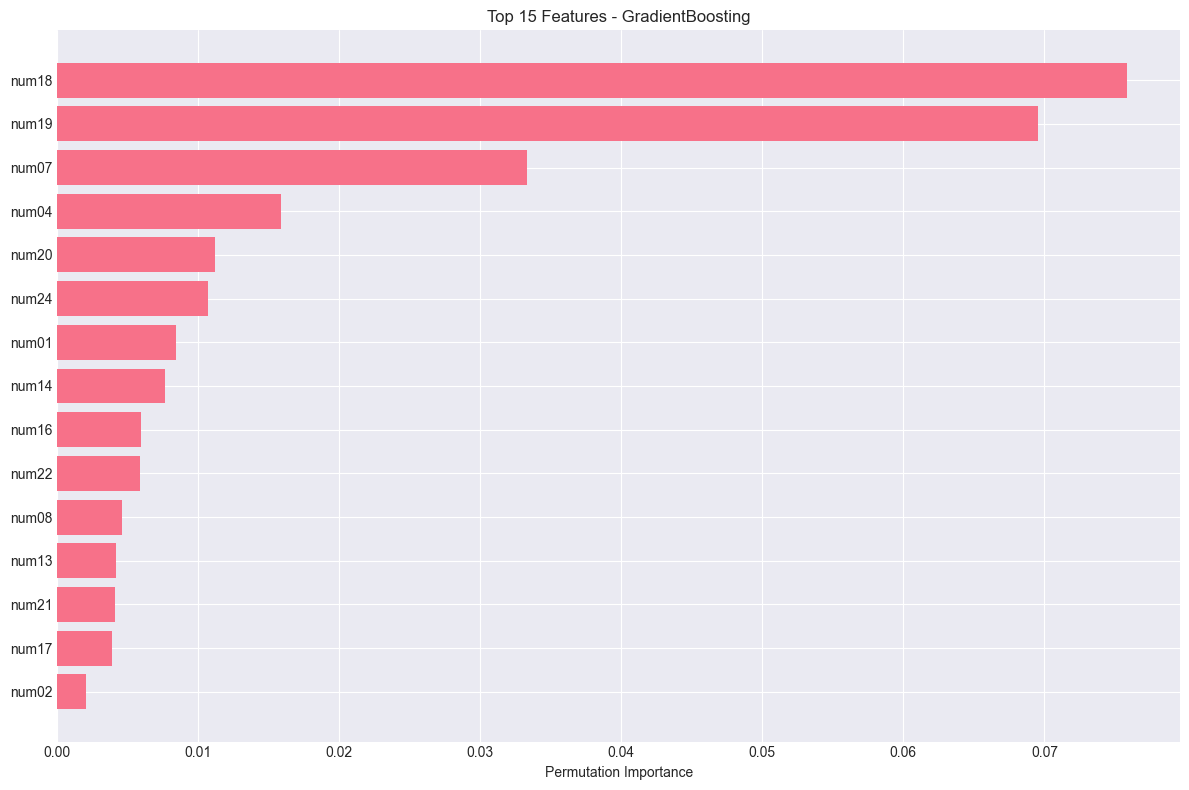

In [33]:
# --- 6. ВИЗУАЛИЗАЦИЯ И АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ ---
print("\n" + "="*60)
print(f"6. АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ: {best_cv_model}")
print("="*60)

best_model = all_models[best_cv_model]

# 6.1. ROC-кривая
plt.figure(figsize=(10, 8))
for name, model in all_models.items():
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', alpha=0.7)

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.2. Confusion Matrix для лучшей модели
plt.figure(figsize=(8, 6))
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_cv_model}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('artifacts/figures/confusion_matrix_best.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.3. Permutation Importance для лучшей модели
print(f"\nPermutation Importance для {best_cv_model}:")
result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='roc_auc'
)

importances = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nТоп-10 важных признаков:")
display(importances.head(10))

# Визуализация
plt.figure(figsize=(12, 8))
top_features = importances.head(15)
plt.barh(top_features['feature'], top_features['importance_mean'])
plt.xlabel('Permutation Importance')
plt.title(f'Top 15 Features - {best_cv_model}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('artifacts/figures/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


In [34]:
# --- 7. СОХРАНЕНИЕ ВСЕХ АРТЕФАКТОВ ---
print("\n" + "="*60)
print("7. СОХРАНЕНИЕ АРТЕФАКТОВ ЭКСПЕРИМЕНТА")
print("="*60)

# 7.1. Сохраняем все метрики
metrics_dict = {m['model']: m for m in all_metrics}
with open('artifacts/metrics_test.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)

# 7.2. Сохраняем лучшую модель
joblib.dump(best_model, 'artifacts/best_model.joblib')

# 7.3. Сохраняем метаданные
best_model_meta = {
    'best_model': best_cv_model,
    'cv_score': best_cv_score,
    'test_metrics': metrics_dict[best_cv_model],
    'feature_importance': importances.head(15).to_dict('records'),
    'experiment_info': {
        'dataset': 'S06-hw-dataset-01.csv',
        'random_state': RANDOM_STATE,
        'test_size': 0.2,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
}

with open('artifacts/best_model_meta.json', 'w') as f:
    json.dump(best_model_meta, f, indent=2)

print(" Все артефакты сохранены:")
print("  - artifacts/search_summaries.json")
print("  - artifacts/metrics_test.json")
print("  - artifacts/best_model.joblib")
print("  - artifacts/best_model_meta.json")
print("  - artifacts/figures/ (графики)")
print("  - artifacts/data_split_info.json")


7. СОХРАНЕНИЕ АРТЕФАКТОВ ЭКСПЕРИМЕНТА
 Все артефакты сохранены:
  - artifacts/search_summaries.json
  - artifacts/metrics_test.json
  - artifacts/best_model.joblib
  - artifacts/best_model_meta.json
  - artifacts/figures/ (графики)
  - artifacts/data_split_info.json


In [35]:
# --- 8. ФИНАЛЬНЫЙ ОТЧЕТ ---
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ УСПЕШНО ЗАВЕРШЕН")
print("="*60)

print(f"\nКлючевые результаты:")
print(f"1. Лучшая модель: {best_cv_model}")
print(f"2. CV ROC-AUC: {best_cv_score:.4f}")
print(f"3. Test Accuracy: {metrics_dict[best_cv_model]['accuracy']:.4f}")
print(f"4. Test F1-score: {metrics_dict[best_cv_model]['f1']:.4f}")
print(f"5. Test ROC-AUC: {metrics_dict[best_cv_model]['roc_auc']:.4f}")

print(f"\nВсе модели (по убыванию ROC-AUC):")
for i, row in metrics_df.iterrows():
    print(f"  {row['model']}: Accuracy={row['accuracy']:.4f}, F1={row['f1']:.4f}, ROC-AUC={row['roc_auc']:.4f}")


ЭКСПЕРИМЕНТ УСПЕШНО ЗАВЕРШЕН

Ключевые результаты:
1. Лучшая модель: GradientBoosting
2. CV ROC-AUC: 0.9727
3. Test Accuracy: 0.9342
4. Test F1-score: 0.8954
5. Test ROC-AUC: 0.9701

Все модели (по убыванию ROC-AUC):
  Stacking: Accuracy=0.9363, F1=0.8997, ROC-AUC=0.9715
  GradientBoosting: Accuracy=0.9342, F1=0.8954, ROC-AUC=0.9701
  RandomForest: Accuracy=0.9275, F1=0.8826, ROC-AUC=0.9687
  DecisionTree: Accuracy=0.8658, F1=0.7821, ROC-AUC=0.9113
  LogisticRegression: Accuracy=0.8271, F1=0.7071, ROC-AUC=0.8752
  Dummy: Accuracy=0.5754, F1=0.3405, ROC-AUC=0.5137
